In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 7

## part 1

In [42]:
np.random.seed(42)
n = 20
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
np.random.shuffle(theta)
x = np.cos(theta)
y = np.sin(theta)
points = np.column_stack((x, y))

def cost_function(x):
    cost = 0
    for i in range(len(x)):
        cost += np.sqrt(np.sum((x[(i+1) % len(x)] - x[i])**2))
    return cost

def swapping(points):
    idx1, idx2 = np.random.choice(len(points), 2, replace=False)
    points[idx1], points[idx2] = points[idx2].copy(), points[idx1].copy()
    return points

def cooling_schedule(k):
    Tk = 1/(np.sqrt(1+k))
    return Tk

def route(points, cost_function, swapping, cooling_schedule, max_iter=10000):
    current_route = np.arange(len(points))
    np.random.shuffle(current_route)
    current_cost = cost_function(points[current_route])
    
    for k in range(max_iter):
        new_route = swapping(current_route.copy())
        new_cost = cost_function(points[new_route])
        
        if new_cost < current_cost:
            current_route, current_cost = new_route, new_cost
        else:
            acceptance_prob = np.exp((current_cost - new_cost) / cooling_schedule(k))
            if np.random.rand() < acceptance_prob:
                current_route, current_cost = new_route, new_cost
    
    return current_route, points[current_route], current_cost

final_route, final_points, final_cost = route(points, cost_function, swapping, cooling_schedule)
print("Final cost:", final_cost)

Final cost: 10.490375103307954


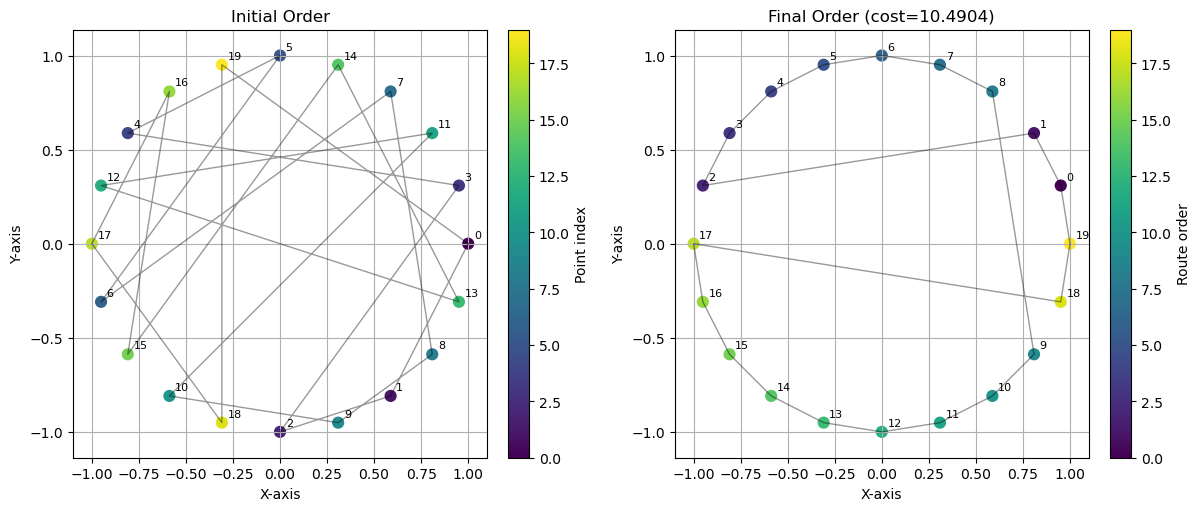

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

norm = plt.Normalize(vmin=0, vmax=len(points) - 1)
idx = np.arange(len(points))

# Initial order
initial_route = np.arange(len(points))
initial_points = points[initial_route]
initial_closed = np.vstack([initial_points, initial_points[0]])

axes[0].plot(initial_closed[:, 0], initial_closed[:, 1], '-k', alpha=0.4, linewidth=1)
sc0 = axes[0].scatter(points[:, 0], points[:, 1], c=idx, cmap='viridis', norm=norm, s=60)

for i, (px, py) in enumerate(points):
    axes[0].text(px + 0.03, py + 0.03, str(i), fontsize=8)

axes[0].set_title("Initial Order")
axes[0].set_xlabel("X-axis")
axes[0].set_ylabel("Y-axis")
axes[0].grid(True)
axes[0].axis("equal")
fig.colorbar(sc0, ax=axes[0], label="Point index")
# Final optimized route
final_points = np.asarray(final_points)
final_closed = np.vstack([final_points, final_points[0]])

final_order_idx = np.arange(len(final_points))

axes[1].plot(final_closed[:, 0], final_closed[:, 1], '-k', alpha=0.4, linewidth=1)

sc1 = axes[1].scatter(
    final_points[:, 0],
    final_points[:, 1],
    c=final_order_idx,
    cmap='viridis',
    s=60
)

for idx, (px, py) in enumerate(final_points):
    axes[1].text(px + 0.03, py + 0.03, str(idx), fontsize=8)

axes[1].set_title(f"Final Order (cost={final_cost:.4f})")
axes[1].set_xlabel("X-axis")
axes[1].set_ylabel("Y-axis")
axes[1].grid(True)
axes[1].axis("equal")

fig.colorbar(sc1, ax=axes[1], label="Route order")

## part2

In [58]:
import pandas as pd
cost = pd.read_csv("cost.csv")
cost

,0,225,110,8,257,22,83,231,277,243,94,30,4,265,274,250,87,83.1,271,86
0,255,0,265,248,103,280,236,91,3,87,274,265,236,8,24,95,247,259,28,259
1,87,236,0,95,248,110,25,274,250,271,9,244,83,250,248,280,29,26,239,7
2,8,280,83,0,236,28,91,239,280,259,103,23,6,280,244,259,95,87,230,84
3,268,87,239,271,0,244,275,9,84,25,244,239,275,83,110,24,274,280,84,274
4,21,265,99,29,259,0,99,230,265,271,87,5,22,239,236,250,87,95,271,91
5,95,236,28,91,247,93,0,247,259,244,27,91,87,268,275,280,7,8,240,27
6,280,83,250,261,4,239,230,0,103,24,239,261,271,95,87,21,274,255,110,280
7,247,9,280,274,84,255,259,99,0,87,255,274,280,3,27,83,259,244,28,274
8,230,103,268,275,23,244,264,28,83,0,268,275,261,91,95,8,277,261,84,247
9,87,239,9,103,261,110,29,255,239,261,0,259,84,239,261,242,24,25,242,5


swap=swap, cool=T1 -> Final cost: 878.0
swap=swap, cool=T2 -> Final cost: 878.0
swap=reverse, cool=T1 -> Final cost: 828.0
swap=reverse, cool=T2 -> Final cost: 828.0

Best setting: swap=reverse, cool=T1 (cost=828.0)


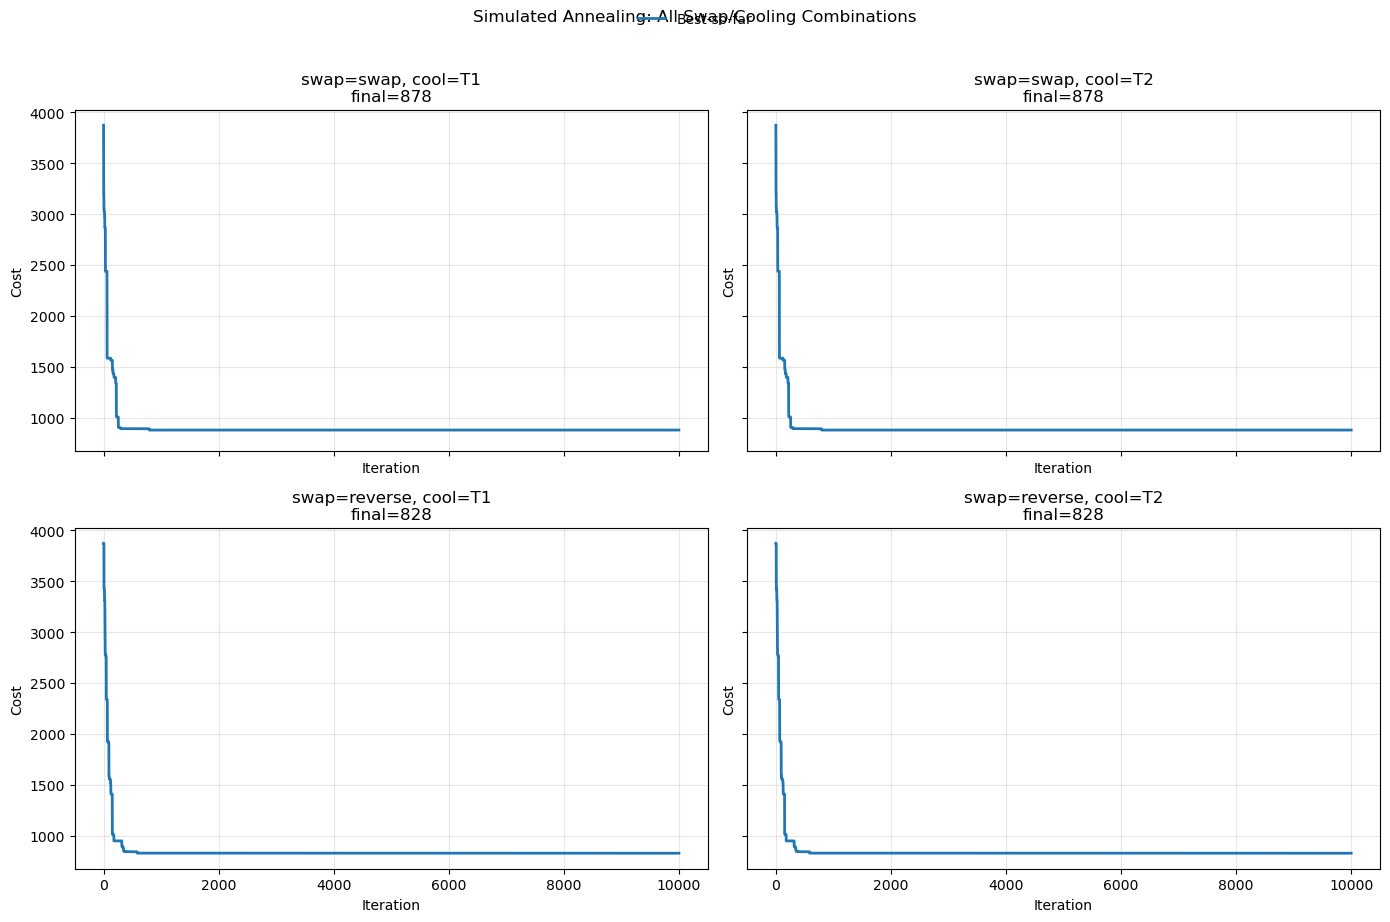

In [81]:
np.random.seed(42)
def swapping(points, method={"swap", "reverse"}):
    if "reverse" in method:
        n = len(points)
        if n >= 2:
            seg_len = np.random.randint(2, n + 1)
            start = np.random.randint(0, n - seg_len + 1)
            end = start + seg_len

            points[start:end] = points[start:end][::-1]
        return points
    else:
        idx1, idx2 = np.random.choice(len(points), 2, replace=False)
        points[idx1], points[idx2] = points[idx2].copy(), points[idx1].copy()
        return points

def cooling_schedule(k, method = {"T1","T2"}):
    if "T1" in method:
        Tk = 1/(np.sqrt(1+k))
    elif "T2" in method:
        Tk = 1/np.log(2+k)
    return Tk

def route(points, cost, swapping, cooling_schedule, max_iter=10000):
    n_nodes = len(points)

    if hasattr(cost, "to_numpy"):
        cost_mat = cost.to_numpy()
    else:
        cost_mat = np.asarray(cost)

    if cost_mat.shape == (n_nodes - 1, n_nodes) and hasattr(cost, "columns"):
        header_vals = (
            pd.Index(cost.columns)
            .astype(str)
            .str.replace(r"\.\d+$", "", regex=True)
        )
        header_vals = pd.to_numeric(header_vals, errors="coerce").to_numpy()
        if len(header_vals) == n_nodes and not np.isnan(header_vals).any():
            cost_mat = np.vstack([header_vals, cost_mat])

    if cost_mat.shape != (n_nodes, n_nodes):
        if "A" in globals() and isinstance(cost, np.ndarray) and cost.shape == (n_nodes, n_nodes):
            cost_mat = cost
        else:
            raise ValueError(f"Cost matrix shape {cost_mat.shape} does not match required {(n_nodes, n_nodes)}.")

    def route_cost(route_idx):
        total = 0.0
        for i in range(n_nodes):
            a = route_idx[i]
            b = route_idx[(i + 1) % n_nodes]
            total += cost_mat[a, b]
        return total

    current_route = np.arange(n_nodes)
    np.random.shuffle(current_route)
    current_cost = route_cost(current_route)

    cost_history = [current_cost]
    best_cost_history = [current_cost]

    for k in range(max_iter):
        new_route = swapping(current_route.copy())
        new_cost = route_cost(new_route)

        if new_cost < current_cost:
            current_route, current_cost = new_route, new_cost
        else:
            acceptance_prob = np.exp((current_cost - new_cost) / cooling_schedule(k))
            if np.random.rand() < acceptance_prob:
                current_route, current_cost = new_route, new_cost

        cost_history.append(current_cost)
        best_cost_history.append(min(best_cost_history[-1], current_cost))

    return current_route, points[current_route], current_cost, cost_history, best_cost_history

swap_methods = ["swap", "reverse"]
cool_methods = ["T1", "T2"]

results = {}

for sm in swap_methods:
    for cm in cool_methods:
        swap_fn = lambda r, sm=sm: swapping(r, method={sm})
        cool_fn = lambda k, cm=cm: cooling_schedule(k, method={cm})
        np.random.seed(42)  # Reset seed for reproducibility
        fr, fp, fc, ch, bch = route(points, cost, swap_fn, cool_fn)

        key = f"swap={sm}, cool={cm}"
        results[key] = {
            "final_route": fr,
            "final_points": fp,
            "final_cost": fc,
            "cost_history": ch,
            "best_cost_history": bch,
        }
        print(f"{key} -> Final cost: {fc}")

best_key = min(results, key=lambda k: results[k]["final_cost"])
print(f"\nBest setting: {best_key} (cost={results[best_key]['final_cost']})")

final_route = results[best_key]["final_route"]
final_points = results[best_key]["final_points"]
final_cost = results[best_key]["final_cost"]
cost_history = results[best_key]["cost_history"]
best_cost_history = results[best_key]["best_cost_history"]
# Plot cost curves for all (swap, cooling) combinations
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (k, v) in zip(axes, results.items()):
    #ax.plot(v["cost_history"], alpha=0.45, label="Current cost")
    ax.plot(v["best_cost_history"], linewidth=2, label="Best-so-far")
    ax.set_title(f"{k}\nfinal={v['final_cost']:.0f}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Cost")
    ax.grid(True, alpha=0.3)

# Single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Simulated Annealing: All Swap/Cooling Combinations", y=1.02)
plt.tight_layout()
plt.show()

# Exercise 8

## part 1

### a

### b

In [95]:
np.random.seed(42)
n =10
Xi = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69])
a = -5
b = 5
n = len(Xi)

mu_hat = np.mean(Xi)

k = 10000
boot_sample = np.random.choice(Xi, size=(k, n), replace=True)
boot_sample_means = np.mean(boot_sample, axis=1)

boot_sample_mean = np.mean(boot_sample_means)

boot_sample_var = 1/(k-1)*np.sum((boot_sample_means - boot_sample_mean)**2)
print("Bootstrap mean:", boot_sample_mean)
print("Bootstrap variance:", boot_sample_var)

diff = boot_sample_means - mu_hat
p_extimate = np.mean((a < diff) & (diff < b))
print("Estimated p-value:", p_extimate)

Bootstrap mean: 76.66464
Bootstrap variance: 17.182345904990502
Estimated p-value: 0.765


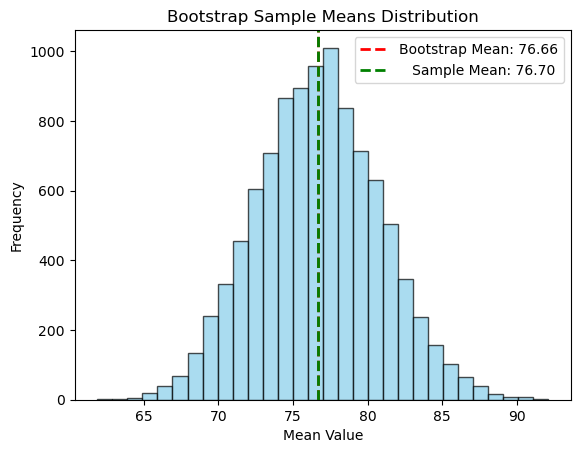

In [94]:
plt.hist(boot_sample_means, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(boot_sample_mean, color='red', linestyle='dashed', linewidth=2, label=f"Bootstrap Mean: {boot_sample_mean:.2f}")
plt.axvline(mu_hat, color='green', linestyle='dashed', linewidth=2, label=f"   Sample Mean: {mu_hat:.2f}")
plt.title("Bootstrap Sample Means Distribution")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")
plt.legend()    

## part 2

In [107]:
np.random.seed(42)
n= 15
Xi = np.array([5,4,9,6,21,17,11,20,7,10,21,15,13,16,8])
mu_hat = np.mean(Xi)

k = 10000
boot_sample = np.random.choice(Xi, size=(k, n), replace=True)

sample_var = np.var(boot_sample,axis = 1, ddof=1)
var = np.var(sample_var, ddof=1)

print("Bootstrap variance:", var)

Bootstrap variance: 59.14528531106535


## part 3

In [ ]:
np.random.seed(42)
def bootstrap(sample, k = 100):
    n = len(sample)
    sample_mean = np.mean(sample)
    sample_median = np.median(sample)

    boot_sample = np.random.choice(sample, size=(k, n), replace=True)

    boot_sample_mean = np.mean(boot_sample, axis=1)
    boot_sample_median = np.median(boot_sample, axis=1)

    var_mean = np.var(boot_sample_mean, ddof=1)
    var_median = np.var(boot_sample_median, ddof=1)
    return sample_median,boot_sample_median, var_median, sample_mean, boot_sample_mean, var_mean

n = 200
u = np.random.rand(n)
sample = (1 - u)**(-1/1.05)

sample_median, boot_sample_median, var_median, sample_mean, boot_sample_mean, var_mean = bootstrap(sample, k=10000)
print(f"Sample median: {sample_median:.4f}, Boot mean: {np.mean(boot_sample_median):.4f}, Variance of median: {var_median:.4f}")
print(f"Sample mean: {sample_mean:.4f}, Boot mean: {np.mean(boot_sample_mean):.4f}, Variance of mean: {var_mean:.4f}")  

Sample median: 1.9150,Boot mean: 1.8674, Variance of median: 0.0225
Sample mean: 4.2260, Boot mean: 4.2240, Variance of mean: 0.2686
